## Analyse des accidents d'avion et des décès jusqu'en 2023

Rapport d'analyse exploratoire, statistique et visuelle sur le jeu de données des accidents d'avion.
Le notebook couvre le nettoyage des données, la création d'indicateurs dérivés, des statistiques descriptives, un test ANOVA via SciPy et plusieurs visualisations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

In [2]:
file_path = r'Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv'
df = pd.read_csv(file_path, encoding='latin1')

for column in ['Aboard', 'Aboard Passangers', 'Aboard Crew', 'Fatalities', 'Fatalities Passangers', 'Fatalities Crew', 'Ground']:
    df[column] = pd.to_numeric(df[column], errors='coerce')

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Decade'] = (df['Year'] // 10) * 10
df['Country'] = df['Location'].fillna('Unknown').astype(str).str.split(',').str[-1].str.strip()
df['Country'] = df['Country'].replace('', 'Unknown')
df['Fatality_Rate'] = np.where(df['Aboard'] > 0, df['Fatalities'] / df['Aboard'], np.nan)
df['Survival_Rate'] = np.where(df['Aboard'] > 0, (df['Aboard'] - df['Fatalities']) / df['Aboard'], np.nan)

display(df.head())
print(f'Rows: {len(df):,}')
print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
print('Missing values (top 10):')
print(df.isna().sum().sort_values(ascending=False).head(10))

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary,Year,Month,Decade,Country,Fatality_Rate,Survival_Rate
0,1908-09-17,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army flyer flown by Orville Wright nos...",1908,9,1900,Virginia,0.5,0.5
1,1909-09-07,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,"Eugene Lefebvre was the first pilot to ever be killed in an air accident, af...",1909,9,1900,France,1.0,0.0
2,1912-07-12,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,"First U.S. dirigible Akron exploded just offshore at an altitude of 1,000 ft...",1912,7,1910,New Jersey,1.0,0.0
3,1913-08-06,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada occurred when American barnstorm...,1913,8,1910,Canada,1.0,0.0
4,1913-09-09,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encountered a severe downdraft cras...,1913,9,1910,Over the North Sea,0.7,0.3


Rows: 4,998
Date range: 1908-09-17 to 2023-11-01
Missing values (top 10):
Flight #                 3669
Time                     1512
Route                     777
cn/ln                     668
Registration              274
Fatalities Passangers     242
Fatalities Crew           241
Aboard Passangers         229
Aboard Crew               226
Summary                    64
dtype: int64


In [6]:
accidents_per_year = df.groupby('Year').size().dropna()
decade_summary = df.groupby('Decade').agg(
    Accidents=('Date', 'size'),
    Mean_Fatalities=('Fatalities', 'mean'),
    Median_Fatalities=('Fatalities', 'median'),
    Mean_Survival=('Survival_Rate', 'mean')
).sort_index()

print('Basic descriptive statistics:')
print(df[['Fatalities', 'Survival_Rate', 'Fatality_Rate']].describe().round(3))
print()
print('Year with the highest number of accidents:', int(accidents_per_year.idxmax()), '(', int(accidents_per_year.max()), 'accidents )')
print()
print('Top 10 countries/regions by accident count:')
print(df['Country'].value_counts().head(10))
print()
display(decade_summary)

Basic descriptive statistics:
       Fatalities  Survival_Rate  Fatality_Rate
count    4990.000       4975.000       4975.000
mean       22.374          0.181          0.819
std        35.062          0.312          0.312
min         0.000          0.000          0.000
25%         4.000          0.000          0.750
50%        11.000          0.000          1.000
75%        25.000          0.250          1.000
max       583.000          1.000          1.000

Year with the highest number of accidents: 1946 ( 88 accidents )

Top 10 countries/regions by accident count:
Country
Russia        257
Brazil        177
Colombia      152
France        125
Canada        125
California    116
India         104
Alaska        103
England       101
Indonesia      98
Name: count, dtype: int64



,Accidents,Mean_Fatalities,Median_Fatalities,Mean_Survival
Decade,,,,
1900,2,1.000000,1.0,0.250000
1910,31,13.677419,18.0,0.032708
1920,182,3.574586,2.0,0.119869
1930,357,5.742938,4.0,0.168412
1940,578,15.445217,14.0,0.153404
1950,649,18.177469,14.0,0.173275
1960,636,26.547170,19.0,0.172948
1970,612,32.272876,17.0,0.201392
1980,552,30.519928,14.0,0.199029


In [4]:
fatalities = df['Fatalities'].dropna()
survival_rates = df['Survival_Rate'].dropna()

fatality_stats = stats.describe(fatalities)
survival_stats = stats.describe(survival_rates)

print('Fatalities distribution:')
print(f'  Mean:   {fatality_stats.mean:.3f}')
print(f'  Median: {np.median(fatalities):.3f}')
print(f'  Std:    {np.sqrt(fatality_stats.variance):.3f}')
print()
print('Survival rate distribution:')
print(f'  Mean:   {survival_stats.mean:.3f}')
print(f'  Median: {np.median(survival_rates):.3f}')
print(f'  Std:    {np.sqrt(survival_stats.variance):.3f}')

periods = {
    '1908-1949': df.loc[df['Year'].between(1908, 1949), 'Fatalities'].dropna(),
    '1950-1979': df.loc[df['Year'].between(1950, 1979), 'Fatalities'].dropna(),
    '1980-2023': df.loc[df['Year'].between(1980, 2023), 'Fatalities'].dropna(),
}
anova_result = stats.f_oneway(*periods.values())
print()
print('ANOVA by period:')
print(f'  F-statistic: {anova_result.statistic:.4f}')
print(f'  p-value:     {anova_result.pvalue:.6f}')
if anova_result.pvalue < 0.05:
    print('  Interpretation: the mean fatalities differ significantly across the periods.')
else:
    print('  Interpretation: no statistically significant difference in mean fatalities across the periods was detected.')

Fatalities distribution:
  Mean:   22.374
  Median: 11.000
  Std:    35.062

Survival rate distribution:
  Mean:   0.181
  Median: 0.000
  Std:    0.312

ANOVA by period:
  F-statistic: 88.3961
  p-value:     0.000000
  Interpretation: the mean fatalities differ significantly across the periods.


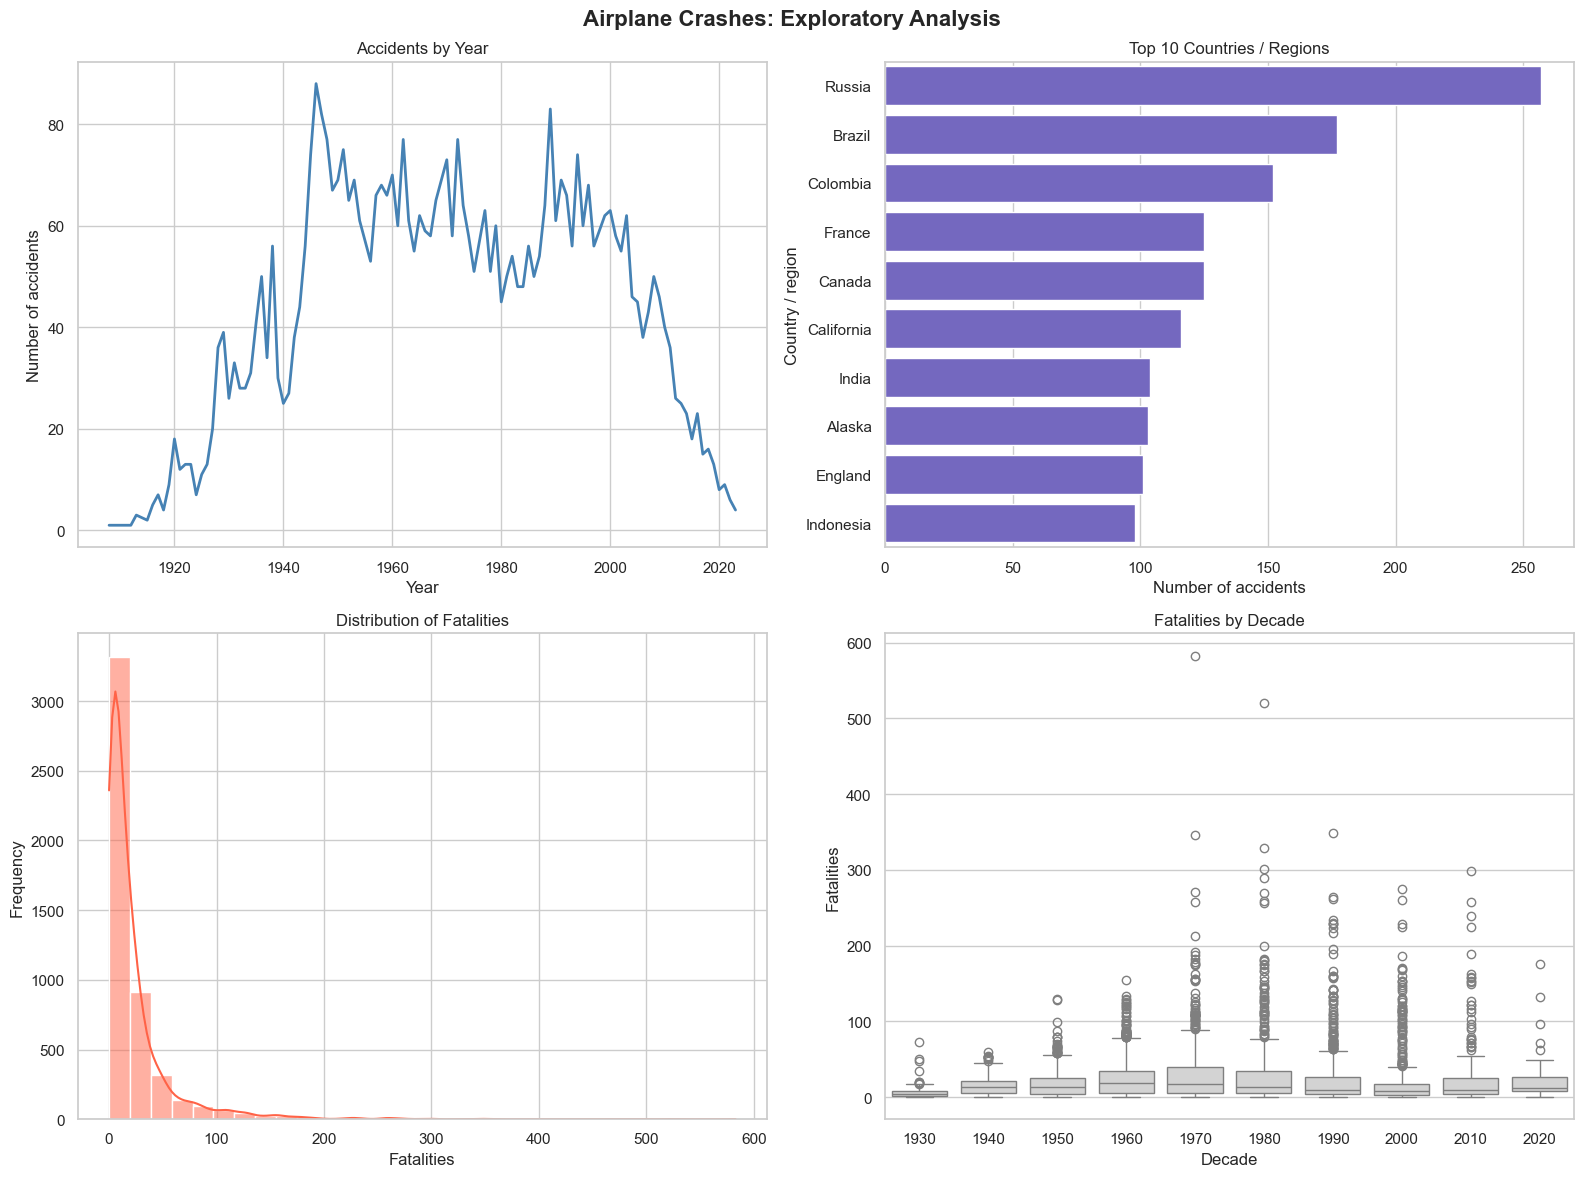

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Airplane Crashes: Exploratory Analysis', fontsize=16, fontweight='bold')

accidents_per_year.plot(ax=axes[0, 0], color='steelblue', linewidth=2)
axes[0, 0].set_title('Accidents by Year')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Number of accidents')

top_countries = df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0, 1], color='slateblue')
axes[0, 1].set_title('Top 10 Countries / Regions')
axes[0, 1].set_xlabel('Number of accidents')
axes[0, 1].set_ylabel('Country / region')

sns.histplot(fatalities, bins=30, kde=True, ax=axes[1, 0], color='tomato')
axes[1, 0].set_title('Distribution of Fatalities')
axes[1, 0].set_xlabel('Fatalities')
axes[1, 0].set_ylabel('Frequency')

decade_box = df[df['Decade'].isin(sorted(df['Decade'].dropna().unique())[-10:])]
sns.boxplot(x='Decade', y='Fatalities', data=decade_box, ax=axes[1, 1], color='lightgray')
axes[1, 1].set_title('Fatalities by Decade')
axes[1, 1].set_xlabel('Decade')
axes[1, 1].set_ylabel('Fatalities')

plt.tight_layout()
plt.show()

## Conclusions

- NumPy is used to compute derived metrics such as fatality and survival rates.
- Pandas is used for loading, cleaning, parsing dates, grouping by year/decade, and summarizing the data.
- SciPy is used for descriptive distribution statistics and the ANOVA hypothesis test.

The visualizations highlight the long-term accident trend, the concentration of incidents in a handful of countries/regions, and the spread of fatalities across events. If the ANOVA p-value is below 0.05, the mean fatalities differ significantly across the selected periods; otherwise, there is not enough evidence to claim a difference.